# Cell 1 - Markdown
"""
# 03 Baseline Modeling

## Student Performance Prediction Using Machine Learning

This notebook trains and evaluates baseline classification models.

Main tasks:
- Load cleaned data
- Define features and target
- Prevent data leakage
- Build preprocessing pipeline
- Train baseline models
- Evaluate models using metrics suitable for imbalanced data
- Save baseline results and confusion matrix summaries
"""

In [1]:
# Cell 2 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cell 3 - Define Paths

PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "StudentPerformanceFactors_cleaned.csv"

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Cleaned data path:", DATA_PATH)
print("Figures directory:", FIGURES_DIR)
print("Tables directory:", TABLES_DIR)

Cleaned data path: ..\data\processed\StudentPerformanceFactors_cleaned.csv
Figures directory: ..\outputs\figures
Tables directory: ..\outputs\tables


In [3]:
# Cell 4 - Load Cleaned Dataset

df = pd.read_csv(DATA_PATH)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Label,Pass_Fail
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,Pass,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,Pass,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Pass,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Pass,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,Pass,1


In [4]:
# Cell 5 - Dataset Overview

print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nTarget Distribution:")
print(df["Performance_Label"].value_counts())

print("\nTarget Percentage:")
print((df["Performance_Label"].value_counts(normalize=True) * 100).round(2))

Dataset Shape:
Rows: 6607
Columns: 22

Target Distribution:
Performance_Label
Pass    6539
Fail      68
Name: count, dtype: int64

Target Percentage:
Performance_Label
Pass    98.97
Fail     1.03
Name: proportion, dtype: float64


In [5]:
# Cell 6 - Define Features and Target

target = "Pass_Fail"

drop_columns = [
    "Exam_Score",
    "Performance_Label",
    "Pass_Fail"
]

X = df.drop(columns=drop_columns)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

X.head()

Feature matrix shape: (6607, 19)
Target vector shape: (6607,)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female


In [6]:
# Cell 7 - Identify Numerical and Categorical Features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [7]:
# Cell 8 - Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Training set shape: (5285, 19)
Testing set shape: (1322, 19)

Training Target Distribution:
Pass_Fail
1    5231
0      54
Name: count, dtype: int64

Testing Target Distribution:
Pass_Fail
1    1308
0      14
Name: count, dtype: int64


In [8]:
# Cell 9 - Build Preprocessing Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [9]:
# Cell 10 - Define Baseline Models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
 'SVM': SVC(probability=True, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

In [10]:
# Cell 11 - Evaluation Function

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_Weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Fail_Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Pass_Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

In [11]:
# Cell 12 - Train and Evaluate Baseline Models

baseline_results = []
trained_pipelines = {}

for model_name, model in models.items():
    print("=" * 70)
    print(f"Training model: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    result = evaluate_model(model_name, y_test, y_pred)
    baseline_results.append(result)

    trained_pipelines[model_name] = pipeline

    print("Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    ))

Training model: Logistic Regression
Classification Report:
              precision    recall  f1-score   support

        Fail       0.89      0.57      0.70        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           0.99      1322
   macro avg       0.94      0.79      0.85      1322
weighted avg       0.99      0.99      0.99      1322

Training model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

        Fail       0.19      0.21      0.20        14
        Pass       0.99      0.99      0.99      1308

    accuracy                           0.98      1322
   macro avg       0.59      0.60      0.60      1322
weighted avg       0.98      0.98      0.98      1322

Training model: Random Forest
Classification Report:
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00        14
        Pass       0.99      1.00      0.99      1308

    accuracy     

In [12]:
# Cell 13 - Baseline Results Table

baseline_results_df = pd.DataFrame(baseline_results)

metric_columns = [
    "Accuracy",
    "Precision_Weighted",
    "Recall_Weighted",
    "F1_Weighted",
    "Macro_F1",
    "Balanced_Accuracy",
    "Fail_Recall",
    "Pass_Recall"
]

baseline_results_df[metric_columns] = baseline_results_df[metric_columns].round(4)

baseline_results_df = baseline_results_df.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    ascending=False
).reset_index(drop=True)

baseline_results_df

,Model,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Pass_Recall
0,Logistic Regression,0.9947,0.9943,0.9947,0.9941,0.8465,0.7853,0.5714,0.9992
1,Gradient Boosting,0.9909,0.9909,0.9909,0.9909,0.7834,0.7834,0.5714,0.9954
2,Decision Tree,0.9818,0.9831,0.9818,0.9824,0.5954,0.6022,0.2143,0.9901
3,SVM,0.9902,0.9903,0.9902,0.9859,0.5642,0.5357,0.0714,1.0000
4,Random Forest,0.9894,0.9789,0.9894,0.9841,0.4973,0.5000,0.0000,1.0000


In [13]:
# Cell 14 - Save Baseline Results

baseline_results_path = TABLES_DIR / "baseline_results.csv"

baseline_results_df.to_csv(baseline_results_path, index=False)

print("Baseline results saved successfully.")
print("Saved to:", baseline_results_path)

Baseline results saved successfully.
Saved to: ..\outputs\tables\baseline_results.csv


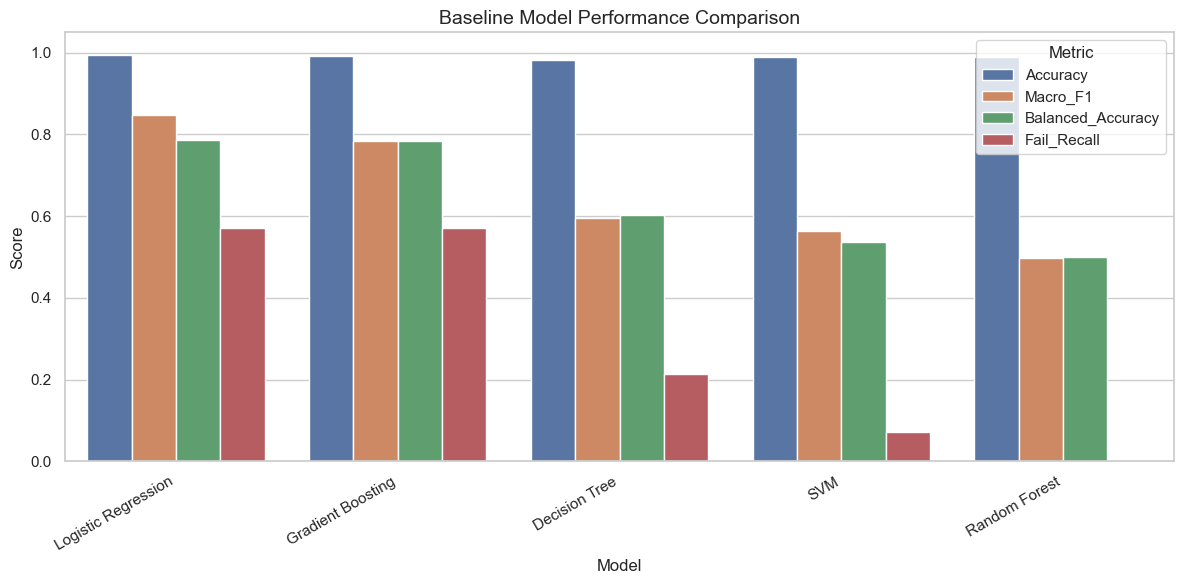

In [14]:
# Cell 15 - Plot Baseline Model Comparison

plt.figure(figsize=(12, 6))

plot_df = baseline_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")

plt.title("Baseline Model Performance Comparison", fontsize=14)
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
# Cell 16 - Confusion Matrix Function

def plot_confusion_matrix_for_model(model_name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Fail", "Predicted Pass"],
        yticklabels=["Actual Fail", "Actual Pass"]
    )

    plt.title(f"Confusion Matrix - {model_name}", fontsize=14)
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()

    file_name = f"confusion_matrix_{model_name.lower().replace(' ', '_')}_baseline.png"
    plt.savefig(FIGURES_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()

    return cm

Confusion Matrix for Logistic Regression


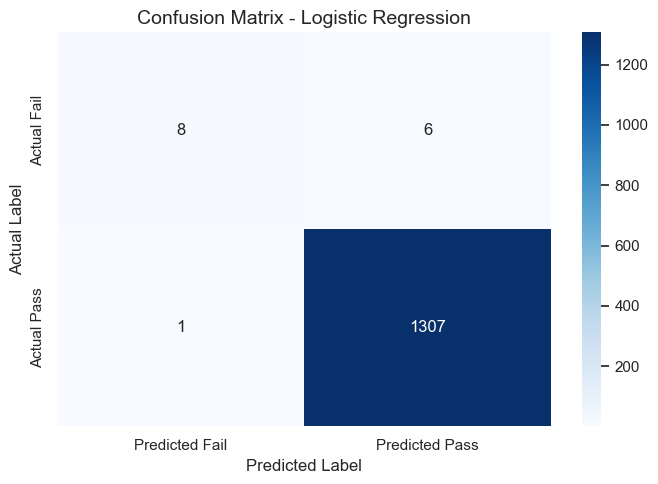

[[   8    6]
 [   1 1307]]
Confusion Matrix for Decision Tree


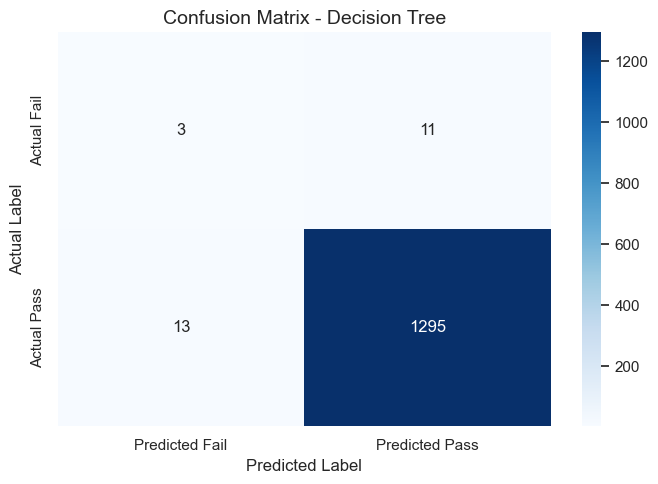

[[   3   11]
 [  13 1295]]
Confusion Matrix for Random Forest


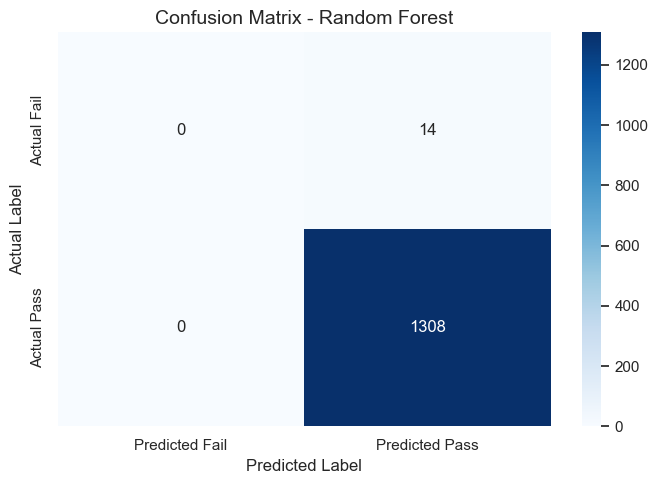

[[   0   14]
 [   0 1308]]
Confusion Matrix for SVM


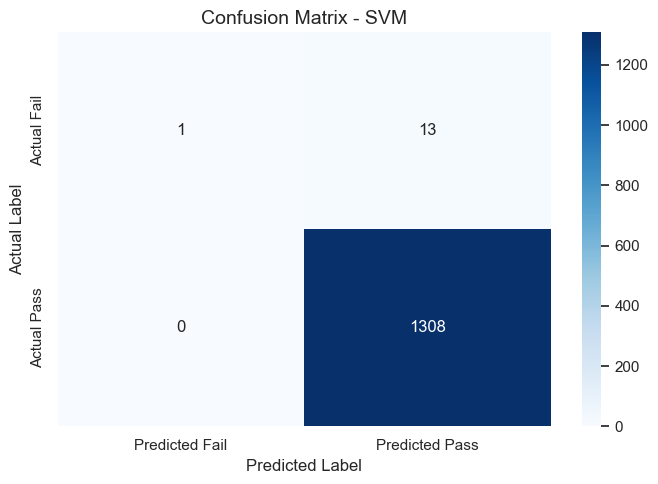

[[   1   13]
 [   0 1308]]
Confusion Matrix for Gradient Boosting


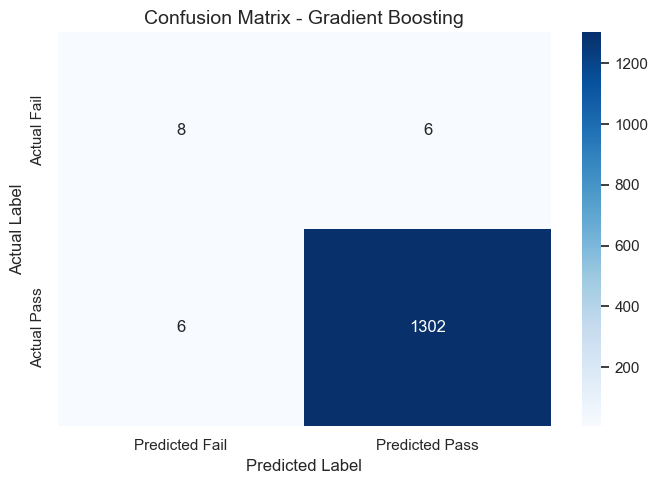

[[   8    6]
 [   6 1302]]


In [16]:
# Cell 17 - Plot Confusion Matrices for All Models

confusion_matrices = {}

for model_name, pipeline in trained_pipelines.items():
    print("=" * 70)
    print(f"Confusion Matrix for {model_name}")

    cm = plot_confusion_matrix_for_model(model_name, pipeline, X_test, y_test)
    confusion_matrices[model_name] = cm

    print(cm)

In [17]:
# Cell 18 - Confusion Matrix Summary Table

confusion_summary = []

for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()

    confusion_summary.append({
        "Model": model_name,
        "True_Fail": tn,
        "Fail_Predicted_As_Pass": fp,
        "Pass_Predicted_As_Fail": fn,
        "True_Pass": tp
    })

confusion_summary_df = pd.DataFrame(confusion_summary)

confusion_summary_df

,Model,True_Fail,Fail_Predicted_As_Pass,Pass_Predicted_As_Fail,True_Pass
0,Logistic Regression,8,6,1,1307
1,Decision Tree,3,11,13,1295
2,Random Forest,0,14,0,1308
3,SVM,1,13,0,1308
4,Gradient Boosting,8,6,6,1302


In [18]:
# Cell 19 - Save Confusion Matrix Summary

confusion_summary_path = TABLES_DIR / "baseline_confusion_matrix_summary.csv"

confusion_summary_df.to_csv(confusion_summary_path, index=False)

print("Baseline confusion matrix summary saved successfully.")
print("Saved to:", confusion_summary_path)

Baseline confusion matrix summary saved successfully.
Saved to: ..\outputs\tables\baseline_confusion_matrix_summary.csv


In [19]:
# Cell 20 - Best Baseline Model

best_baseline_model_name = baseline_results_df.iloc[0]["Model"]
best_baseline_pipeline = trained_pipelines[best_baseline_model_name]

print("Best Baseline Model Based on Macro F1, Balanced Accuracy, and Fail Recall:")
print(best_baseline_model_name)

baseline_results_df.iloc[0]

Best Baseline Model Based on Macro F1, Balanced Accuracy, and Fail Recall:
Logistic Regression


Model                 Logistic Regression
Accuracy                           0.9947
Precision_Weighted                 0.9943
Recall_Weighted                    0.9947
F1_Weighted                        0.9941
Macro_F1                           0.8465
Balanced_Accuracy                  0.7853
Fail_Recall                        0.5714
Pass_Recall                        0.9992
Name: 0, dtype: object

In [20]:
# Cell 21 - Detailed Report for Best Baseline Model

y_pred_best_baseline = best_baseline_pipeline.predict(X_test)

print("Best Baseline Model:", best_baseline_model_name)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best_baseline,
    target_names=["Fail", "Pass"],
    zero_division=0
))

Best Baseline Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        Fail       0.89      0.57      0.70        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           0.99      1322
   macro avg       0.94      0.79      0.85      1322
weighted avg       0.99      0.99      0.99      1322



In [21]:
# Cell 22 - Save Baseline Modeling Summary

baseline_summary_path = TABLES_DIR / "baseline_modeling_summary.txt"

best_baseline_row = baseline_results_df.iloc[0]

baseline_summary_text = f"""
Baseline Modeling Summary

Models tested:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM
5. Gradient Boosting

Best baseline model:
{best_baseline_row["Model"]}

Best baseline performance:
Accuracy: {best_baseline_row["Accuracy"]}
Macro F1: {best_baseline_row["Macro_F1"]}
Balanced Accuracy: {best_baseline_row["Balanced_Accuracy"]}
Fail Recall: {best_baseline_row["Fail_Recall"]}

Important observation:
Although several models achieved high accuracy, accuracy alone is not reliable because the dataset is highly imbalanced.
The most important metric for this project is Fail Recall because the goal is to identify students at risk of failing.
"""

with open(baseline_summary_path, "w", encoding="utf-8") as file:
    file.write(baseline_summary_text)

print("Baseline modeling summary saved successfully.")
print("Saved to:", baseline_summary_path)

Baseline modeling summary saved successfully.
Saved to: ..\outputs\tables\baseline_modeling_summary.txt


In [22]:
# Cell 23 - Save Train/Test Splits

X_train.to_csv(TABLES_DIR / "X_train_baseline.csv", index=False)
X_test.to_csv(TABLES_DIR / "X_test_baseline.csv", index=False)
y_train.to_csv(TABLES_DIR / "y_train_baseline.csv", index=False)
y_test.to_csv(TABLES_DIR / "y_test_baseline.csv", index=False)

print("Train/test split files saved successfully.")

Train/test split files saved successfully.


In [24]:
# Cell 24 - Final Output Check

print("Baseline Modeling Output Files Created")
print("-" * 50)

print("\nFigures:")
for file in sorted(FIGURES_DIR.glob("*baseline*.png")):
    print("-", file.name)

print("\nTables:")
for file in sorted(TABLES_DIR.glob("*baseline*.csv")):
    print("-", file.name)

print("\nText Summaries:")
for file in sorted(TABLES_DIR.glob("*baseline*.txt")):
    print("-", file.name)

Baseline Modeling Output Files Created
--------------------------------------------------

Figures:
- baseline_model_comparison.png
- confusion_matrix_decision_tree_baseline.png
- confusion_matrix_gradient_boosting_baseline.png
- confusion_matrix_logistic_regression_baseline.png
- confusion_matrix_random_forest_baseline.png
- confusion_matrix_svm_baseline.png

Tables:
- baseline_confusion_matrix_summary.csv
- baseline_results.csv
- X_test_baseline.csv
- X_train_baseline.csv
- y_test_baseline.csv
- y_train_baseline.csv

Text Summaries:
- baseline_modeling_summary.txt


# Cell 25 - Markdown
"""
## Baseline Modeling Summary

Several baseline machine learning models were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. Gradient Boosting

The dataset was split into 80% training and 20% testing using stratified sampling.

Exam_Score was removed from the input features to prevent data leakage.

The baseline results showed that accuracy alone is not reliable because the dataset is highly imbalanced.

The next notebook will focus on imbalance handling, threshold tuning, and hyperparameter tuning.
"""